## Evaluating ACS Performance for an OTV with Varying Payload Configurations

The Attitude Control System (ACS) governs the orientation of a spacecraft and is essential for mission-critical operations such as communication alignment, thermal regulation, safety, and payload delivery. Large spacecraft like Orbital Transfer Vehicles (OTVs), such as Blue Origin’s Blue Ring, require advanced ACS strategies to manage the high rotational inertias associated with transporting large payloads.

OTVs often dock with external payloads, which can significantly alter the spacecraft’s mass distribution and rotational moment of inertia. Effective control schemes must adapt to these changes to ensure stability and performance.

In this project, I simulate how different payload configurations affect ACS performance. The OTV is modeled as a simplified rigid cylinder, and the payload as a rigid cube mounted at varying positions. Using the Parallel Axis Theorem, I compute the composite moment of inertia. Then, I simulate the spacecraft’s rotational behavior using Euler’s rotational equations. The simulation assumes a torque-only environment with no external forces or disturbances.

A PD controller is applied to regulate the vehicle's roll angle, and its performance is evaluated through a step response from 0° to 30°. Key performance metrics such as rise time, overshoot, and settling time are computed to assess control effectiveness under varying inertia conditions.

A list of simplifications used to complete this investigation: 
- The inertia of the Blue Ring OTV was simplified to a cylinder.
- The mass of the model for Blue Ring is assumed to be 2000kg, based on estimates of other OTV's.
- The dimensions of the model are estimated based on pictures, and the ships ability to fit inside the 7m diam. fairing of New Glenn.
- The inertia of the payload was simplified to a cube.
- The mass of the payload was assumed to be 500kg for simplification.
- The side length of the cube is 1m, again for simplification.
- The actuators that apply torques in the principal axes are deterministic, have no delay, and do not saturate.
- There is no noise in the sensors, controllers, acutators, or system. The experiment is deterministic.

Setup:
- A cube(Payload) is attached tangent to the curved surface of the cylinder(OTV).
- Vary the position of the payload along the length of the cylinder.
- Keep the model of the OTV and the payload constant.

Important Equations for Simulation:
- Dynamics are described by the Euler Rotation Equations
-- this is great for describing the rotation of a rigid floating body because all components are defined in the rotating reference frame(OTV). This applies to our model because the actuators apply the torques in the rotating frame of the vehicle.
- The dynamics described by differential equations are propogated forward using Euler Integration. This is a standard simplified method for estimating continuous differential equations. Accuracy is decent by not the best technique. 
- The Parallel Axis Theorem was used to estimate the moment of inertia of the composite shape, OTV + Payload. This theorem allows us to estimate the moment of inertia of the payload when we rotate it about an axis that is parallel to it's centroidal axis. In our case, when the payload is attached to the outside of the OTV, it will rotate about the principal axes of the OTV.

Hypothesis:
Mounting the payload farther from the principal axes of the orbital transfer vehicle (OTV) will degrade the performance of the attitude controller, due to the increased angular moment of inertia.

Further Research:
- More accuracy in ODE evaluation using using RungeKutta.
- Better accuracy of the system model by improving the inertia estimates of the Blue Ring. 
- Better controllers. LQR, MPC, gain scheduling.
- Incorporating estimates of noise in the model for the system or measurement devices.
- Statistics on the probablity of achieved stabilization in a stochastic system. PDF representing the likelhood of stability within the performance metrics(rise/settling time).
- Additional variations of the payload setup, i.e. varying the mass of the payload in addition to it's location.
- Simulate the response to a desired target state that requires more actuation than just one degree of rotation. 
- Incorporating dynamics of actuators.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
class OrbitalTransferVehicle:
    def __init__(self, t_span, z_pay, m_body = 2000, r_body = 2.5, h_body = 5, m_pay = 500, s_pay = 1, K_p = 20, K_d = 400):
        """
        Initialize the OTV.
        """
        self.delta_t = 0.01
        self.x = np.zeros((6, 1))  # initial conditions for the state vector
        self.t = 0.0
        self.t_span = t_span # final time of simulation

        self.m_body = m_body
        self.r = r_body
        self.h = h_body

        self.m_pay = m_pay  # mass of payload
        self.s_pay = s_pay
        self.x_pay = 0
        self.y_pay = r_body + s_pay / 2 # distance from the center of mass to the payload in y direction
        self.z_pay = z_pay

        self.I = self.set_inertia()

        self.K_p = K_p
        self.K_d = K_d
    
    def set_inertia(self):
        """
        Set the inertia matrix based on the mass of the payload.
        """
        # Inertia matrix for a cylindrical body
        m = self.m_body
        r = self.r
        h = self.h

        I_cyc = np.array([1/12*m*(3*r**2 + h**2), 1/12*m*(3*r**2 + h**2), 1/2*m*r**2]) # Ixx, Iyy, Izz
        print("Inertia Matrix (Cylindrical Body):", I_cyc)

        m_pay = self.m_pay
        s_pay = self.s_pay  # m, side length of the payload cube
        I_pay = np.array([1/6*m_pay*s_pay**2, 1/6*m_pay*s_pay**2, 1/6*m_pay*s_pay**2])

        # parallel axis theorm, rotate about the satellite body principle axis
        # I = I_cm + m * d^2
        d_x = np.sqrt(self.y_pay**2 + self.z_pay**2)  # distance from the center of mass to the payload in x direction
        d_y = np.sqrt(self.z_pay**2 + self.x_pay**2)  # "                                                " y direction
        d_z = np.sqrt(self.x_pay**2 + self.y_pay**2)  # "                                                " z direction

        I_comp = I_cyc + I_pay + np.array([m_pay*d_x**2, m_pay*d_y**2, m_pay*d_z**2]) # x, y, z adjustment to inertia matrix
        print("Inertia Matrix (Cylindrical Body + Payload):", I_comp)

        return I_comp

    def cntrl(self, x, x_d):
        """
        Compute the control input based on the current state and desired state.
        """
        assert x.shape == (6, 1)
        assert x_d.shape == (6, 1)

        e = x - x_d

        # PD <- PID will need to remember error, bigger state
        u_1 = -1 * (self.K_p * e[0] + self.K_d * e[3])
        u_2 = -1 * (self.K_p * e[1] + self.K_d * e[4])
        u_3 = -1 * (self.K_p * e[2] + self.K_d * e[5])
        u = np.array([[u_1], [u_2], [u_3]])  # control input
        u.resize((3, 1))  # ensure shape is (3, 1)
        assert u.shape == (3, 1)

        return u

    def dyn(self, x, u):
        """
        Compute the state derivative based on the current state, inertia, and control input.
        """
        assert x.shape == (6, 1)

        I_1, I_2, I_3 = self.I
        M_1, M_2, M_3 = u

        x_dot = np.zeros((6, 1))  # Initialize the state derivative

        x_dot[0] = x[3]
        x_dot[1] = x[4]
        x_dot[2] = x[5]
        
        # Euler's Rotation Equations
        x_dot[3] = 1/I_1 * (M_1 - (I_3 - I_2) * x[4] * x[5])
        x_dot[4] = 1/I_2 * (M_2 - (I_1 - I_3) * x[5] * x[3])
        x_dot[5] = 1/I_3 * (M_3 - (I_2 - I_1) * x[3] * x[4])

        return x_dot
    
    def sim(self, x_d):
        """
        Simulate the system dynamics over the specified time span.
        """

        while self.t < self.t_span:
            curr_x = self.x[:,-1].reshape(-1, 1)

            # Compute Control Input
            u = self.cntrl(curr_x, x_d)

            # Compute State Derivative
            x_dot = self.dyn(curr_x, u)
            assert x_dot.shape == (6, 1)

            # Simulate the system using Euler Integration
            next_x = curr_x + x_dot * self.delta_t
            self.x = np.hstack((self.x, next_x))
            
            self.t += self.delta_t

        return self.x
    
    def plot(self, ax=None):
        """
        Plot the state variables of the OTV over time.
        """

        if ax is None:
            ax = plt.gca()

        ax.plot(self.x[0, :], label='Roll - x')
        ax.plot(self.x[1, :], label='Pitch - y')
        ax.plot(self.x[2, :], label='Yaw - z')
        #ax.plot(self.x[3, :], label='Omega 1', linestyle='--')
        #ax.plot(self.x[4, :], label='Omega 2', linestyle='--')
        #ax.plot(self.x[5, :], label='Omega 3', linestyle='--')
        plt.title(f'PD Controller Kp={self.K_p}, Kd={self.K_d}')
        plt.hlines(y=np.pi/6, xmin=0, xmax=self.x.shape[1]-1, colors='r', linestyles='dashed', label='Desired Roll (30 degrees)')
        plt.xlabel('Time Steps')
        plt.ylabel('State Values')
        plt.legend()


### Roll Control Simulation

Simulate a step response to the desired orientation of 30deg around the x-axis (roll). This simplifies the test to one degree of rotation.

In [19]:
x_desired = np.array([[np.pi/6], [0], [0], [0], [0], [0]])  # Desired state vector, 30deg roll, no pitch or yaw, no angular velocity

t_span = 300

otv_payload_none = OrbitalTransferVehicle(z_pay=0, t_span = t_span, m_pay=0)
otv_payload_none.sim(x_desired)

otv_payload_cntr = OrbitalTransferVehicle(z_pay=0, t_span = t_span)
otv_payload_cntr.sim(x_desired)

otv_payload_1m = OrbitalTransferVehicle(z_pay=1, t_span = t_span)
otv_payload_1m.sim(x_desired)

otv_payload_5m = OrbitalTransferVehicle(z_pay=5, t_span = t_span)
otv_payload_5m.sim(x_desired)

Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [11875.          7375.         10833.33333333]
Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [12375.          7875.         10833.33333333]
Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [24375.         19875.         10833.33333333]


array([[0.00000000e+00, 0.00000000e+00, 4.29619508e-08, ...,
        5.27755727e-01, 5.27768143e-01, 5.27780557e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 4.29619508e-06, 8.59168515e-06, ...,
        1.24163001e-03, 1.24139215e-03, 1.24115422e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

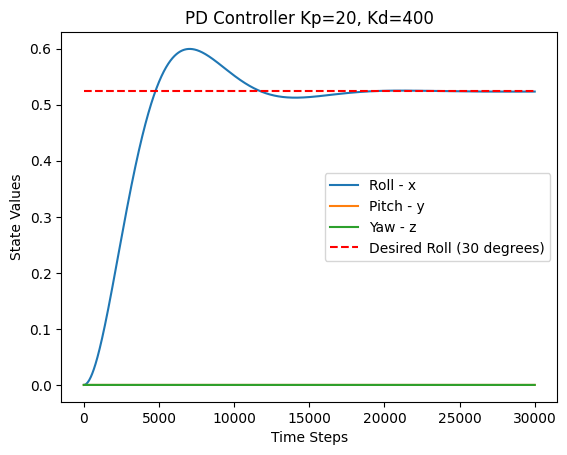

In [20]:
# Glance at results
otv_payload_none.plot()

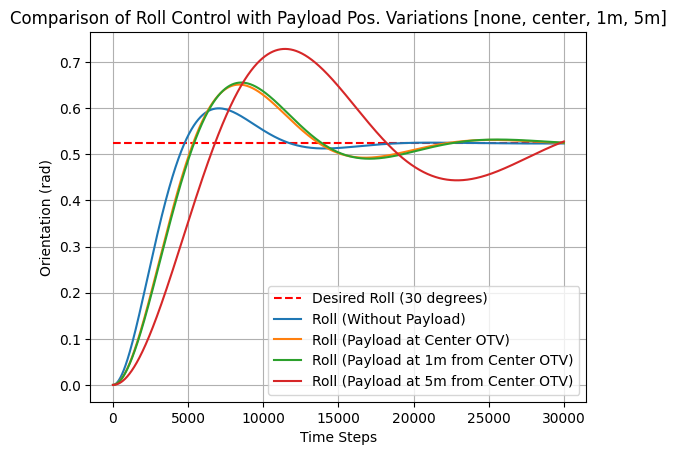

In [21]:
# Plot and Compare the trajectories that the OTV takes with different payload positions
plt.figure()

plt.hlines(y=np.pi/6, xmin=0, xmax=otv_payload_none.x.shape[1]-1, colors='r', linestyles='dashed', label='Desired Roll (30 degrees)')
plt.plot(otv_payload_none.x[0, :], label='Roll (Without Payload)')
plt.plot(otv_payload_cntr.x[0, :], label='Roll (Payload at Center OTV)')
plt.plot(otv_payload_1m.x[0, :], label='Roll (Payload at 1m from Center OTV)')
plt.plot(otv_payload_5m.x[0, :], label='Roll (Payload at 5m from Center OTV)')

plt.title('Comparison of Roll Control with Payload Pos. Variations [none, center, 1m, 5m]')
plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Orientation (rad)')
plt.grid()
plt.show()

Data - recorded by eye
Test                           = rise-time | overshoot | settling time

Without Payload                = 4500 - 1200 / 100, .1/.5 * 100, 200 sec

Payload Mounted at Center      = 5000 - 1250 / 100, .15/.5 * 100, 300 sec

Payload Mounted 1m from Center = 5000 - 1250 / 100, .15/.5 * 100, 300 sec

Payload Mounted 5m from Center = 6200 - 1300 / 100, .225 / .5 *100, > 300 sec

## Results

Test                           = rise-time | overshoot | settling time
Without Payload                = 33 sec    |    20%    |  200 sec
Payload Mounted at Center      = 37.5 sec  |    30%    |  300 sec
Payload Mounted 1m from Center = 37.5 sec  |    30%    |  300 sec
Payload Mounted 5m from Center = 49 sec    |    45%    | >300 sec

Observations:
As the payload is mounted farther from the center of the OTV, controller performance degrades. Specifically, the rise time increases, overshoot becomes more pronounced, and the settling time grows longer. The most significant decline in performance occurs when the payload is placed 5 meters from the center, indicating a substantial increase in the system’s angular moment of inertia.

Interestingly, the controller performance shows minimal difference between the payload mounted at the center and at a 1-meter offset. This suggests that for a payload of this mass, small displacements from the principal axis have a negligible impact on inertia. This observation aligns with the structure of the Parallel Axis Theorem, where the offset contribution scales with the square of the distance (d^2), meaning small distances contribute very little to the total inertia.

## Conculsion
The simulation results confirm the original hypothesis: as the payload is mounted farther from the principal axis of the orbital transfer vehicle (OTV), the spacecraft’s moment of inertia increases, leading to degraded control performance. Specifically, the PD controller exhibited slower rise time, higher overshoot, and longer settling time under these conditions.

This highlights an important consideration for GNC engineers — the position of docked payloads significantly affects attitude dynamics, and control algorithms must account for these changes in real-time. If I were tasked with designing a flight-ready ACS controller, I would explore a gain-scheduling strategy. This well-established technique allows for predefined controller gains to adapt to different inertial configurations during mission phases such as payload docking.

To implement this, I would run a series of simulations across a range of payload positions and inertia values to build a reliable gain schedule. This schedule could be loaded onboard and selected in real-time as the spacecraft configuration changes. Additionally, I would request the mass and inertia tensor of expected payloads in advance to precompute stable gain sets for each docking scenario.

Another possible extension is to explore online optimal control techniques, such as adaptive LQR or model predictive control (MPC) using gradient descent to find gains in real time. However, I would approach this with caution — relying purely on optimization could result in gain values that push actuators to their saturation limits or produce unstable responses if the system encounters an unmodeled or extreme payload configuration.

Overall, this project demonstrates that even simple controllers require thoughtful integration with the physical configuration of a spacecraft. A robust ACS must be aware of its changing inertia, especially in modular or serviceable vehicles like the Blue Ring platform.

In [ ]:
jupyter nbconvert --execute --to markdown sim.ipynb